# ACS-SegNet on SegPath — Endothelium Only

**Paper:** ACS-SegNet: An Attention-based CNN-SegFormer Segmentation Network for Tissue Segmentation in Histopathology  
**Dataset:** SegPath — Endothelium subset only (100 images + 100 masks)  
**Task:** Binary segmentation (endothelium tissue vs background)

> This notebook trains ACS-SegNet **exclusively on the Endothelium cell type** from SegPath.
> Epithelium and Smooth Muscle are excluded for a cleaner single-class experiment.
>
> ⚠️ **Known data caveat:** 67/100 Endothelium masks are entirely empty (no foreground pixels).
> Only 33 tiles have labeled tissue. Expect lower/noisier IoU and Dice than the other two classes,
> and watch fold splits carefully — a fold with an unlucky majority of empty-mask val samples
> can produce degenerate metrics (precision/recall undefined when there's no positive class).


## Cell 1 — Install Dependencies

In [1]:
# ── Install all required packages ──────────────────────────────────────────────
# FIX: pin segmentation-models-pytorch to 0.3.4 -- the last release before the
# `use_batchnorm` -> `use_norm` rename in Conv2dReLU (smp 0.4.0+). ACS-SegNet's
# unet_decoder/decoder.py calls Conv2dReLU(use_batchnorm=...), which breaks on
# unpinned/newer smp with: TypeError: Conv2dReLU.__init__() got an unexpected
# keyword argument 'use_batchnorm'
!pip install -q transformers segmentation-models-pytorch==0.3.4 albumentations timm==0.9.0
!pip install -q matplotlib scikit-learn

import torch
print(f'PyTorch        : {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Cannot install segmentation-models-pytorch==0.3.4 and timm==0.9.0 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts
PyTorch        : 2.11.0+cu128
CUDA available : True
GPU            : Tesla T4


## Cell 2 — Mount Google Drive & Unzip Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

# ── EDIT: path to the zip you uploaded in Google Drive ─────────────────────────
DRIVE_ZIP_PATH = '/content/drive/MyDrive/SegPath_sorted.zip'
EXTRACT_DIR    = '/content/SegPath_sorted'
# ───────────────────────────────────────────────────────────────────────────────

if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset ...')
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    print('Done.')
else:
    print('Dataset already extracted.')

# ── Verify counts ──────────────────────────────────────────────────────────────
print()
print(f'{"Cell Type":<20}  {"Images":>8}  {"Masks":>8}')
print('-' * 42)
for ct in ['endothelium']:   # Endothelium-only run
    img_dir  = os.path.join(EXTRACT_DIR, ct, 'images')
    mask_dir = os.path.join(EXTRACT_DIR, ct, 'masks')
    n_imgs   = len([f for f in os.listdir(img_dir)  if not f.startswith('.')]) if os.path.exists(img_dir)  else 0
    n_masks  = len([f for f in os.listdir(mask_dir) if not f.startswith('.')]) if os.path.exists(mask_dir) else 0
    status   = '✓' if n_imgs == n_masks else '✗ MISMATCH'
    print(f'{ct:<20}  {n_imgs:>8}  {n_masks:>8}  {status}')

Mounted at /content/drive
Extracting dataset ...
Done.

Cell Type               Images     Masks
------------------------------------------
endothelium                100       100  ✓


## Cell 3 — Clone ACS-SegNet Repository

In [3]:
import os
REPO_DIR = '/content/ACS-SegNet'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/NimaTorbati/ACS-SegNet.git {REPO_DIR}
else:
    print('Repo already cloned.')

os.chdir(REPO_DIR)
print('Working directory:', os.getcwd())
print('Top-level files  :', [f for f in os.listdir('.') if not f.startswith('.')])

Cloning into '/content/ACS-SegNet'...
remote: Enumerating objects: 319, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 319 (delta 35), reused 10 (delta 2), pack-reused 256 (from 1)
Receiving objects: 100% (319/319), 319.56 KiB | 6.52 MiB/s, done.
Resolving deltas: 100% (154/154), done.
Working directory: /content/ACS-SegNet
Top-level files  : ['src', 'data', 'model', 'checkpoint', 'README.md', 'DGAUNet_train.py', 'train.py', 'utils', 'model.py', 'ModelWeights', 'Puma_Train.py', 'networks', 'unet_decoder']


## Cell 4 — Configuration

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  — only edit this cell
# ═══════════════════════════════════════════════════════════════════════════════

CFG = {
    # ── Dataset ───────────────────────────────────────────────────────────────
    'data_root'  : '/content/SegPath_sorted',
    'data_dir'   : '/content/ACS_data_endothelium',   # separate folder from other runs

    # Endothelium only — epithelium and smooth_muscle excluded
    # NOTE: 67/100 endothelium masks are entirely empty (no foreground). See Cell 6b scan.
    'cell_types' : {
        'endothelium': ('_HE', '_mask'),
    },

    # ── Model ─────────────────────────────────────────────────────────────────
    'img_size'      : 256,
    'num_classes'   : 1,      # binary segmentation
    'segformer_var' : 'nvidia/segformer-b2-finetuned-ade-512-512',
    'resnet_enc'    : 'resnet34',
    'decoder_ch'    : (256, 128, 64, 32, 16),
    'simple_fusion' : 1,      # 1 = ACS-SegNet (CBAM)

    # ── Training ──────────────────────────────────────────────────────────────
    'epochs'        : 100,
    'batch_size'    : 4,      # safe for T4 GPU at 256 px; reduce to 2 if OOM
    'lr'            : 0.01,
    'momentum'      : 0.9,
    'weight_decay'  : 1e-4,
    'n_folds'       : 3,      # 3-fold CV on 100 endothelium samples (67 train / 33 val per fold)
    'seed'          : 42,

    # ── Output paths ──────────────────────────────────────────────────────────
    'checkpoint_dir': '/content/checkpoints_endothelium',
    'result_dir'    : '/content/results_endothelium',
    'drive_save'    : '/content/drive/MyDrive/ACS_SegNet_Endothelium',  # separate Drive folder
}

import os
for d in [CFG['data_dir'], CFG['checkpoint_dir'], CFG['result_dir'], CFG['drive_save']]:
    os.makedirs(d, exist_ok=True)

print('Configuration ready — Endothelium-only run.')
print(f'  Merged data    : {CFG["data_dir"]}')
print(f'  Checkpoints    : {CFG["checkpoint_dir"]}')
print(f'  Drive backup   : {CFG["drive_save"]}')
print()
print('NOTE: 100 endothelium tiles → 3-fold CV → ~67 train / ~33 val per fold.')
print('      All masks are {0,1} label-encoded; (mask > 0) binarisation is applied.')
print('      WARNING: 67/100 endothelium masks are entirely empty (no foreground) — see Cell 6b.')


Configuration ready — Endothelium-only run.
  Merged data    : /content/ACS_data_endothelium
  Checkpoints    : /content/checkpoints_endothelium
  Drive backup   : /content/drive/MyDrive/ACS_SegNet_Endothelium

NOTE: 100 endothelium tiles → 3-fold CV → ~67 train / ~33 val per fold.
      All masks are {0,1} label-encoded; (mask > 0) binarisation is applied.


## Cell 5 — Build Endothelium Dataset + 3-Fold Split Files

This cell:
1. Scans `endothelium/images/` for `*_HE.png` files
2. Strips `_HE` suffix to get the base ID
3. Looks for the paired `<base_id>_mask.png` in `endothelium/masks/`
4. Copies both into a flat `ACS_data_endothelium/images/` and `.../masks/` directory
5. Writes `SegPath{fold}_train.txt` / `SegPath{fold}_val.txt` split files (3 folds over 100 samples)

⚠️ Because 67/100 masks are empty, the random 3-fold split is **not stratified by foreground
presence** — some folds may end up with a disproportionate share of empty-mask validation tiles.
Check the Cell 6b scan output and the per-fold sample counts below before trusting IoU comparisons
across folds.


In [5]:
import os, shutil, random
import numpy as np

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])

merged_imgs  = os.path.join(CFG['data_dir'], 'images')
merged_masks = os.path.join(CFG['data_dir'], 'masks')
os.makedirs(merged_imgs,  exist_ok=True)
os.makedirs(merged_masks, exist_ok=True)

all_stems   = []   # flat list of unified stems for the dataloader
skipped     = []   # pairs where the mask was not found

for ct, (img_sfx, msk_sfx) in CFG['cell_types'].items():
    img_src  = os.path.join(CFG['data_root'], ct, 'images')
    msk_src  = os.path.join(CFG['data_root'], ct, 'masks')

    # Collect every image file that ends with the expected image suffix
    img_files = sorted([
        f for f in os.listdir(img_src)
        if f.lower().endswith('.png') and (img_sfx.lower() in f.lower())
    ])

    print(f'\n{ct}: found {len(img_files)} image files')

    paired = 0
    for fname in img_files:
        # ── Derive base ID by stripping the image suffix + extension ──────────
        # e.g. 'ERG_Endothelium_024_067584_052224_HE.png'  →  'ERG_Endothelium_024_067584_052224'
        ext     = os.path.splitext(fname)[1]           # '.png'
        no_ext  = os.path.splitext(fname)[0]           # '..._HE'
        if no_ext.endswith(img_sfx):
            base_id = no_ext[: -len(img_sfx)]          # strip '_HE'
        else:
            base_id = no_ext                           # fallback: use full stem

        mask_fname = base_id + msk_sfx + ext           # e.g. '..._mask.png'
        src_mask   = os.path.join(msk_src, mask_fname)

        if not os.path.exists(src_mask):
            skipped.append(f'{ct}/{fname}  →  missing {mask_fname}')
            continue

        # ── Build a collision-safe unified stem for the merged dataset ─────────
        # e.g.  'endothelium__ERG_Endothelium_024_067584_052224'
        unified_stem = f'{ct}__{base_id}'

        # ── Copy image ────────────────────────────────────────────────────────
        dst_img = os.path.join(merged_imgs,  unified_stem + '.png')
        if not os.path.exists(dst_img):
            shutil.copy(os.path.join(img_src, fname), dst_img)

        # ── Copy mask ─────────────────────────────────────────────────────────
        dst_msk = os.path.join(merged_masks, unified_stem + '.png')
        if not os.path.exists(dst_msk):
            shutil.copy(src_mask, dst_msk)

        all_stems.append(unified_stem)
        paired += 1

    print(f'  Successfully paired: {paired}')

# ── Report any missing masks ───────────────────────────────────────────────────
if skipped:
    print(f'\nWARNING — {len(skipped)} image(s) had no matching mask:')
    for s in skipped: print(' ', s)

print(f'\nTotal paired samples: {len(all_stems)}')

# ── 3-Fold cross-validation split ─────────────────────────────────────────────
random.shuffle(all_stems)
folds = np.array_split(all_stems, CFG['n_folds'])

print(f'\n3-Fold split summary:')
for i in range(CFG['n_folds']):
    val_stems   = list(folds[i])
    train_stems = [s for j, fold in enumerate(folds) for s in fold if j != i]

    with open(os.path.join(CFG['data_dir'], f'SegPath{i}_train.txt'), 'w') as f:
        f.write('\n'.join(train_stems))
    with open(os.path.join(CFG['data_dir'], f'SegPath{i}_val.txt'), 'w') as f:
        f.write('\n'.join(val_stems))

    # Per-class counts inside this fold's val set
    counts = {ct: sum(1 for s in val_stems if s.startswith(ct)) for ct in CFG['cell_types']}
    print(f'  Fold {i}:  train={len(train_stems):3d}  val={len(val_stems):3d}  '
          f'({"  ".join(f"{ct[:4]}={n}" for ct,n in counts.items())})')

print('\nSplit files written to:', CFG['data_dir'])


endothelium: found 100 image files
  Successfully paired: 100

Total paired samples: 100

3-Fold split summary:
  Fold 0:  train= 66  val= 34  (endo=34)
  Fold 1:  train= 67  val= 33  (endo=33)
  Fold 2:  train= 67  val= 33  (endo=33)

Split files written to: /content/ACS_data_endothelium


## Cell 6 — Verify a Sample from Endothelium

endothelium           img=(984, 984, 3)  mask unique=[0 1]  foreground=0.0%


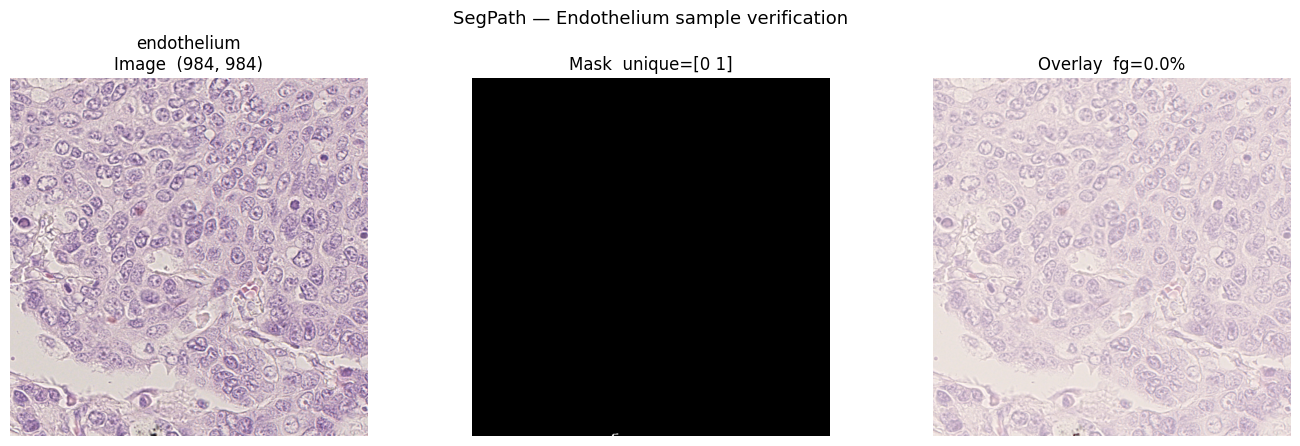

In [7]:
import cv2, matplotlib.pyplot as plt, numpy as np

# Pick one sample per cell type for visual verification
samples = {ct: None for ct in CFG['cell_types']}
for stem in all_stems:
    ct = stem.split('__')[0]
    if samples[ct] is None:
        samples[ct] = stem
    if all(v is not None for v in samples.values()):
        break

fig, axes = plt.subplots(len(samples), 3, figsize=(14, 4.5 * len(samples)), squeeze=False)

for row, (ct, stem) in enumerate(samples.items()):
    img  = cv2.cvtColor(
        cv2.imread(os.path.join(CFG['data_dir'], 'images', stem + '.png')),
        cv2.COLOR_BGR2RGB
    )
    mask = cv2.imread(os.path.join(CFG['data_dir'], 'masks', stem + '.png'), cv2.IMREAD_GRAYSCALE)
    # NOTE: SegPath masks may be label-encoded {0,1} rather than {0,255} binary masks.
    # mask_vis is rescaled purely for *display* (imshow); mask itself stays raw for the unique() check.
    mask_vis = (mask > 0).astype('uint8') * 255

    # Print diagnostic info
    uniq = np.unique(mask)
    coverage = round(100 * (mask > 0).sum() / mask.size, 1)   # FIX: was `mask > 127`, which silently
                                                                #      zeroed out coverage for {0,1}-encoded masks
    print(f'{ct:<20}  img={img.shape}  mask unique={uniq}  foreground={coverage}%')

    axes[row][0].imshow(img)
    axes[row][0].set_title(f'{ct}\nImage  {img.shape[:2]}')
    axes[row][0].axis('off')

    axes[row][1].imshow(mask_vis, cmap='gray')   # FIX: display the rescaled mask, not the raw {0,1} values
    axes[row][1].set_title(f'Mask  unique={uniq}')
    axes[row][1].axis('off')

    overlay = img.copy()
    axes[row][2].imshow(overlay)
    axes[row][2].imshow(mask_vis, alpha=0.45, cmap='Reds')   # FIX: same rescaling for the overlay
    axes[row][2].set_title(f'Overlay  fg={coverage}%')
    axes[row][2].axis('off')

plt.suptitle('SegPath — Endothelium sample verification', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CFG['drive_save'], 'sample_verification.png'), dpi=120, bbox_inches='tight')
plt.show()

## Cell 6b — Scan Endothelium Masks (0/1 vs 0/255 check + empty-mask audit)

In [8]:
import os, numpy as np, cv2
from collections import defaultdict

print("Scanning all masks for value-encoding consistency...\n")
stats = defaultdict(lambda: {'unique_sets': set(), 'n_empty': 0, 'n_files': 0, 'max_val': 0})

for stem in all_stems:
    ct = stem.split('__')[0]
    mask_path = os.path.join(CFG['data_dir'], 'masks', stem + '.png')
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f'  WARNING: could not read {mask_path}')
        continue
    uniq = tuple(np.unique(mask).tolist())
    stats[ct]['unique_sets'].add(uniq)
    stats[ct]['n_files'] += 1
    stats[ct]['max_val'] = max(stats[ct]['max_val'], int(mask.max()))
    if mask.max() == 0:
        stats[ct]['n_empty'] += 1

print(f"{'cell_type':<16} {'n_files':>8} {'n_empty':>8} {'max_val':>8}  distinct_unique_value_sets")
for ct, s in stats.items():
    shown = sorted(s['unique_sets'], key=lambda t: (len(t), t))[:5]
    suffix = ' ...' if len(s['unique_sets']) > 5 else ''
    print(f"{ct:<16} {s['n_files']:>8} {s['n_empty']:>8} {s['max_val']:>8}  {shown}{suffix}")

print("\nInterpretation:")
print("  max_val == 1   -> masks are label-encoded {0,1}, NOT {0,255}.")
print("                    The original `/255.0` then `>0.5` binarisation step zeroes EVERY mask -- training bug.")
print("  max_val == 255 -> masks are standard 0/255 binary masks (no issue).")
print("  n_empty > 0    -> some masks have zero foreground pixels. Could be a legitimate negative tile,")
print("                    or a data/copy issue -- worth spot-checking a few of those stems manually.")


Scanning all masks for value-encoding consistency...

cell_type         n_files  n_empty  max_val  distinct_unique_value_sets
endothelium           100       67        1  [(0,), (0, 1)]

Interpretation:
  max_val == 1   -> masks are label-encoded {0,1}, NOT {0,255}.
                    The original `/255.0` then `>0.5` binarisation step zeroes EVERY mask -- training bug.
  max_val == 255 -> masks are standard 0/255 binary masks (no issue).
  n_empty > 0    -> some masks have zero foreground pixels. Could be a legitimate negative tile,
                    or a data/copy issue -- worth spot-checking a few of those stems manually.


## Cell 7 — Model, Dataset & Loss Definitions

In [10]:
import sys, os, random
sys.path.insert(0, '/content/ACS-SegNet')

# --- FIX: Ensure segmentation-models-pytorch is installed correctly ---
# The previous installation in Cell 1 failed due to a dependency conflict
# between segmentation-models-pytorch==0.3.4 and timm==0.9.0.
# segmentation-models-pytorch==0.3.4 requires timm==0.4.12.
# We uninstall any conflicting timm version and then install smp==0.3.4.
# The -y flag to uninstall automatically confirms yes.
!pip uninstall -y timm
!pip install -q segmentation-models-pytorch==0.3.4
# ---------------------------------------------------------------------

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
from albumentations import (
    Compose, RandomRotate90, HorizontalFlip, Resize,
    HueSaturationValue, RandomBrightnessContrast, GaussNoise
)

# ACS-SegNet repo modules
from model import DualEncoderUNet
from src.utils.metrics import iou_score
from src.utils.util import AverageMeter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


# ── Reproducibility ───────────────────────────
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED']       = str(seed)

seed_everything(CFG['seed'])


# ── Dataset ─────────────────────────────
class SegPathDataset(Dataset):
    """
    Reads the merged flat dataset:
      <data_dir>/images/<unified_stem>.png
      <data_dir>/masks/<unified_stem>.png
    where unified_stem = '<cell_type>__<base_id>'
    e.g.  endothelium__ERG_Endothelium_024_067584_052224
    """
    def __init__(self, data_dir, split_file, transform=None):
        self.data_dir  = data_dir
        self.transform = transform
        with open(split_file, 'r') as f:
            self.stems = [l.strip() for l in f if l.strip()]
        print(f'  [{os.path.basename(split_file)}]  {len(self.stems)} samples')

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        img_path  = os.path.join(self.data_dir, 'images', stem + '.png')
        mask_path = os.path.join(self.data_dir, 'masks',  stem + '.png')

        # Load image (RGB) and mask (grayscale)
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)[..., None]  # (H,W,1)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']

        # Normalise image to [0,1] and convert to (C,H,W)
        image = (image.astype('float32') / 255.0).transpose(2, 0, 1)   # (3,H,W)

        # FIX: SegPath masks may be label-encoded {0,1} OR standard {0,255} binary masks.
        # The original `/255.0` + `>0.5` logic silently zeroed out every {0,1}-encoded mask
        # (1/255 ≈ 0.0039, never > 0.5), so the model trained against empty targets.
        # `> 0` works correctly for both encodings.
        mask = (mask > 0).astype('float32').transpose(2, 0, 1)         # (1,H,W), binarised

        return {
            'image': torch.tensor(image),
            'label': torch.tensor(mask),
            'stem' : stem,
        }


# ── Loss (BCEDice ─ identical to the original ACS-SegNet codebase) ──────────
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        bce    = F.binary_cross_entropy_with_logits(pred, target)
        smooth = 1e-5
        p      = torch.sigmoid(pred)
        n      = target.size(0)
        p_f    = p.view(n, -1)
        t_f    = target.view(n, -1)
        inter  = (p_f * t_f).sum(1)
        dice   = 1 - ((2 * inter + smooth) / (p_f.sum(1) + t_f.sum(1) + smooth)).mean()
        return 0.5 * bce + dice


# ── Build ACS-SegNet (DualEncoderUNet with CBAM) ───────────────
def build_model():
    model = DualEncoderUNet(
        unet_encoder_name    = CFG['resnet_enc'],          # resnet34
        unet_encoder_weights = 'imagenet',
        segformer_variant    = CFG['segformer_var'],        # segformer-b2
        classes              = CFG['num_classes'],          # 1
        decoder_channels     = CFG['decoder_ch'],           # (256,128,64,32,16)
        simple_fusion        = CFG['simple_fusion'],        # 1 = CBAM
        regression           = False,
        in_channels          = 3,
        model_depth          = 5,
        IgnoreBottleNeck     = False,
        input_size           = CFG['img_size'],
    ).to(DEVICE)
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  ACS-SegNet parameters: {n/1e6:.1f} M')
    return model


print('All definitions loaded.')

Found existing installation: timm 1.0.27
Uninstalling timm-1.0.27:
  Successfully uninstalled timm-1.0.27
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.1 MB/s eta 0:00:00
Device: cuda
All definitions loaded.


## Cell 8 — DataLoaders + Training / Validation Functions

In [11]:
import time
from collections import defaultdict


def get_dataloaders(fold_idx):
    S = CFG['img_size']

    # Augmentation pipeline (matches the paper: flip, rotate, + intensity augments)
    train_tf = Compose([
        RandomRotate90(p=0.5),
        HorizontalFlip(p=0.5),
        HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
        RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        GaussNoise(p=0.2),
        Resize(S, S),
    ])
    val_tf = Compose([Resize(S, S)])

    train_ds = SegPathDataset(
        CFG['data_dir'],
        os.path.join(CFG['data_dir'], f'SegPath{fold_idx}_train.txt'),
        transform=train_tf,
    )
    val_ds = SegPathDataset(
        CFG['data_dir'],
        os.path.join(CFG['data_dir'], f'SegPath{fold_idx}_val.txt'),
        transform=val_tf,
    )

    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                              shuffle=False, num_workers=2)
    return train_loader, val_loader


# ── One training epoch (poly-LR decay matching the paper) ───────────────────────
def train_one_epoch(model, loader, optimizer, criterion,
                    iter_num, max_iters, base_lr):
    model.train()
    meters = {k: AverageMeter() for k in ['loss', 'iou', 'dice']}

    for batch in loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        preds = model(imgs)
        loss  = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Poly LR
        lr_now = base_lr * (1.0 - iter_num / max_iters) ** 0.9
        for pg in optimizer.param_groups:
            pg['lr'] = lr_now
        iter_num += 1

        iou, dice, *_ = iou_score(preds, labels)
        bs = imgs.size(0)
        meters['loss'].update(loss.item(), bs)
        meters['iou'].update(iou,  bs)
        meters['dice'].update(dice, bs)

    return meters, iter_num


# ── Validation pass ─────────────────────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    keys   = ['loss', 'iou', 'dice', 'SE', 'PC', 'F1', 'SP', 'ACC']
    meters = {k: AverageMeter() for k in keys}

    for batch in loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        preds  = model(imgs)
        loss   = criterion(preds, labels)
        iou, dice, SE, PC, F1, SP, ACC = iou_score(preds, labels)
        bs = imgs.size(0)
        for k, v in zip(keys, [loss.item(), iou, dice, SE, PC, F1, SP, ACC]):
            meters[k].update(v, bs)

    return meters


print('Dataloader and loop functions defined.')

Dataloader and loop functions defined.


## Cell 9 — Full Training Loop (3-Fold CV — Endothelium Only)

In [12]:
import shutil

fold_results   = {}   # fold_idx → best val IoU
fold_histories = {}   # fold_idx → metric history dict
last_model      = None
last_val_loader = None


def run_fold(fold_idx):
    print(f'\n{"="*65}')
    print(f'  FOLD {fold_idx + 1} / {CFG["n_folds"]}')
    print(f'{"="*65}')

    train_loader, val_loader = get_dataloaders(fold_idx)
    model     = build_model()
    criterion = BCEDiceLoss().to(DEVICE)
    optimizer = optim.SGD(
        model.parameters(),
        lr=CFG['lr'], momentum=CFG['momentum'], weight_decay=CFG['weight_decay']
    )

    max_iters = CFG['epochs'] * len(train_loader)
    iter_num  = 0
    best_iou  = 0.0
    history   = defaultdict(list)
    ckpt_path = os.path.join(CFG['checkpoint_dir'], f'ACSSegNet_fold{fold_idx}_best.pth')

    for epoch in range(1, CFG['epochs'] + 1):
        t0 = time.time()

        train_m, iter_num = train_one_epoch(
            model, train_loader, optimizer, criterion,
            iter_num, max_iters, CFG['lr']
        )
        val_m = validate(model, val_loader, criterion)
        elapsed = time.time() - t0

        # Record history
        for k in train_m:
            history[f'train_{k}'].append(train_m[k].avg)
        for k in val_m:
            history[f'val_{k}'].append(val_m[k].avg)

        # Log every 10 epochs (and epoch 1)
        if epoch == 1 or epoch % 10 == 0:
            print(
                f'  Ep {epoch:3d}/{CFG["epochs"]}  '
                f'loss={train_m["loss"].avg:.4f}  iou={train_m["iou"].avg:.4f} | '
                f'val_loss={val_m["loss"].avg:.4f}  val_iou={val_m["iou"].avg:.4f}  '
                f'val_dice={val_m["dice"].avg:.4f}  [{elapsed:.1f}s]'
            )

        # Save best checkpoint
        if val_m['iou'].avg > best_iou:
            best_iou = val_m['iou'].avg
            torch.save(model.state_dict(), ckpt_path)
            print(f'  ★ Best val_iou={best_iou:.4f}  (epoch {epoch}) — saved')

    # Mirror best checkpoint to Google Drive
    shutil.copy(ckpt_path, os.path.join(CFG['drive_save'], os.path.basename(ckpt_path)))
    print(f'\nFold {fold_idx} done.  Best val IoU = {best_iou:.4f}')

    return best_iou, dict(history), model, val_loader


# ── Run all folds ────────────────────────────────────────────────────────────────
for fi in range(CFG['n_folds']):
    best_iou, history, model, val_loader = run_fold(fi)
    fold_results[fi]   = best_iou
    fold_histories[fi] = history
    last_model          = model
    last_val_loader     = val_loader

# ── Cross-validation summary ─────────────────────────────────────────────────────
ious = list(fold_results.values())
print(f'\n{"="*65}')
print(' CROSS-VALIDATION SUMMARY — ACS-SegNet on SegPath (Endothelium Only)')
print(f'{"="*65}')
for i, iou in enumerate(ious):
    dice_approx = (2 * iou) / (iou + 1)
    print(f'  Fold {i}:  IoU = {iou:.4f}   Dice ≈ {dice_approx:.4f}')
print(f'  Mean IoU  = {np.mean(ious):.4f} ± {np.std(ious):.4f}')
mean_dice = np.mean([(2*v)/(v+1) for v in ious])
print(f'  Mean Dice ≈ {mean_dice:.4f}')


  FOLD 1 / 3
  [SegPath0_train.txt]  66 samples
  [SegPath0_val.txt]  34 samples
Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 226MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

...

[transformers] SegformerModel LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | UNEXPECTED |  | 
decode_head.batch_norm.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.num_batches_tracked    | UNEXPECTED |  | 
decode_head.batch_norm.running_mean           | UNEXPECTED |  | 
decode_head.batch_norm.weight                 | UNEXPECTED |  | 
decode_head.linear_fuse.weight                | UNEXPECTED |  | 
decode_head.classifier.bias                   | UNEXPECTED |  | 
decode_head.classifier.weight                 | UNEXPECTED |  | 
decode_head.batch_norm.running_var            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ACS-SegNet parameters: 50.4 M
  Ep   1/100  loss=1.1736  iou=0.0602 | val_loss=1.1493  val_iou=0.2727  val_dice=0.2727  [10.5s]
  ★ Best val_iou=0.2727  (epoch 1) — saved
  Ep  10/100  loss=1.0036  iou=0.1791 | val_loss=1.0027  val_iou=0.2727  val_dice=0.2727  [6.9s]
  Ep  20/100  loss=1.0020  iou=0.1791 | val_loss=1.0034  val_iou=0.2727  val_dice=0.2727  [8.9s]
  Ep  30/100  loss=1.0017  iou=0.1194 | val_loss=1.0028  val_iou=0.2727  val_dice=0.2727  [9.0s]
  Ep  40/100  loss=0.9964  iou=0.2388 | val_loss=1.0009  val_iou=0.2727  val_dice=0.2727  [6.9s]
  Ep  50/100  loss=0.9959  iou=0.1194 | val_loss=1.0015  val_iou=0.2727  val_dice=0.2727  [7.2s]
  Ep  60/100  loss=0.9828  iou=0.1194 | val_loss=0.9978  val_iou=0.2727  val_dice=0.2727  [8.7s]
  Ep  70/100  loss=0.9813  iou=0.2388 | val_loss=1.0028  val_iou=0.2727  val_dice=0.2727  [7.5s]
  Ep  80/100  loss=0.9711  iou=0.1194 | val_loss=1.0013  val_iou=0.2727  val_dice=0.2727  [7.0s]
  Ep  90/100  loss=0.9652  iou=0.1791 | val_loss=1.

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | UNEXPECTED |  | 
decode_head.batch_norm.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.num_batches_tracked    | UNEXPECTED |  | 
decode_head.batch_norm.running_mean           | UNEXPECTED |  | 
decode_head.batch_norm.weight                 | UNEXPECTED |  | 
decode_head.linear_fuse.weight                | UNEXPECTED |  | 
decode_head.classifier.bias                   | UNEXPECTED |  | 
decode_head.classifier.weight                 | UNEXPECTED |  | 
decode_head.batch_norm.running_var            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ACS-SegNet parameters: 50.4 M
  Ep   1/100  loss=1.1490  iou=0.1046 | val_loss=1.2155  val_iou=0.1515  val_dice=0.1515  [8.7s]
  ★ Best val_iou=0.1515  (epoch 1) — saved
  Ep  10/100  loss=1.0031  iou=0.0597 | val_loss=1.0039  val_iou=0.1515  val_dice=0.1515  [8.9s]
  Ep  20/100  loss=1.0022  iou=0.1642 | val_loss=1.0036  val_iou=0.1515  val_dice=0.1515  [7.5s]
  Ep  30/100  loss=1.0014  iou=0.1194 | val_loss=1.0031  val_iou=0.1515  val_dice=0.1515  [6.9s]
  Ep  40/100  loss=0.9989  iou=0.1194 | val_loss=0.9986  val_iou=0.1515  val_dice=0.1515  [8.9s]
  Ep  50/100  loss=0.9940  iou=0.2239 | val_loss=0.9961  val_iou=0.1515  val_dice=0.1515  [7.8s]
  Ep  60/100  loss=0.9879  iou=0.1642 | val_loss=1.0004  val_iou=0.1515  val_dice=0.1515  [6.9s]
  Ep  70/100  loss=0.9873  iou=0.1791 | val_loss=0.9920  val_iou=0.1515  val_dice=0.1515  [8.8s]
  Ep  80/100  loss=0.9827  iou=0.1194 | val_loss=0.9962  val_iou=0.1515  val_dice=0.1515  [8.8s]
  Ep  90/100  loss=0.9777  iou=0.2388 | val_loss=0.9

In [ ]:
import segmentation_models_pytorch as smp
print(smp.__version__)

## Cell 10 — Training Curves

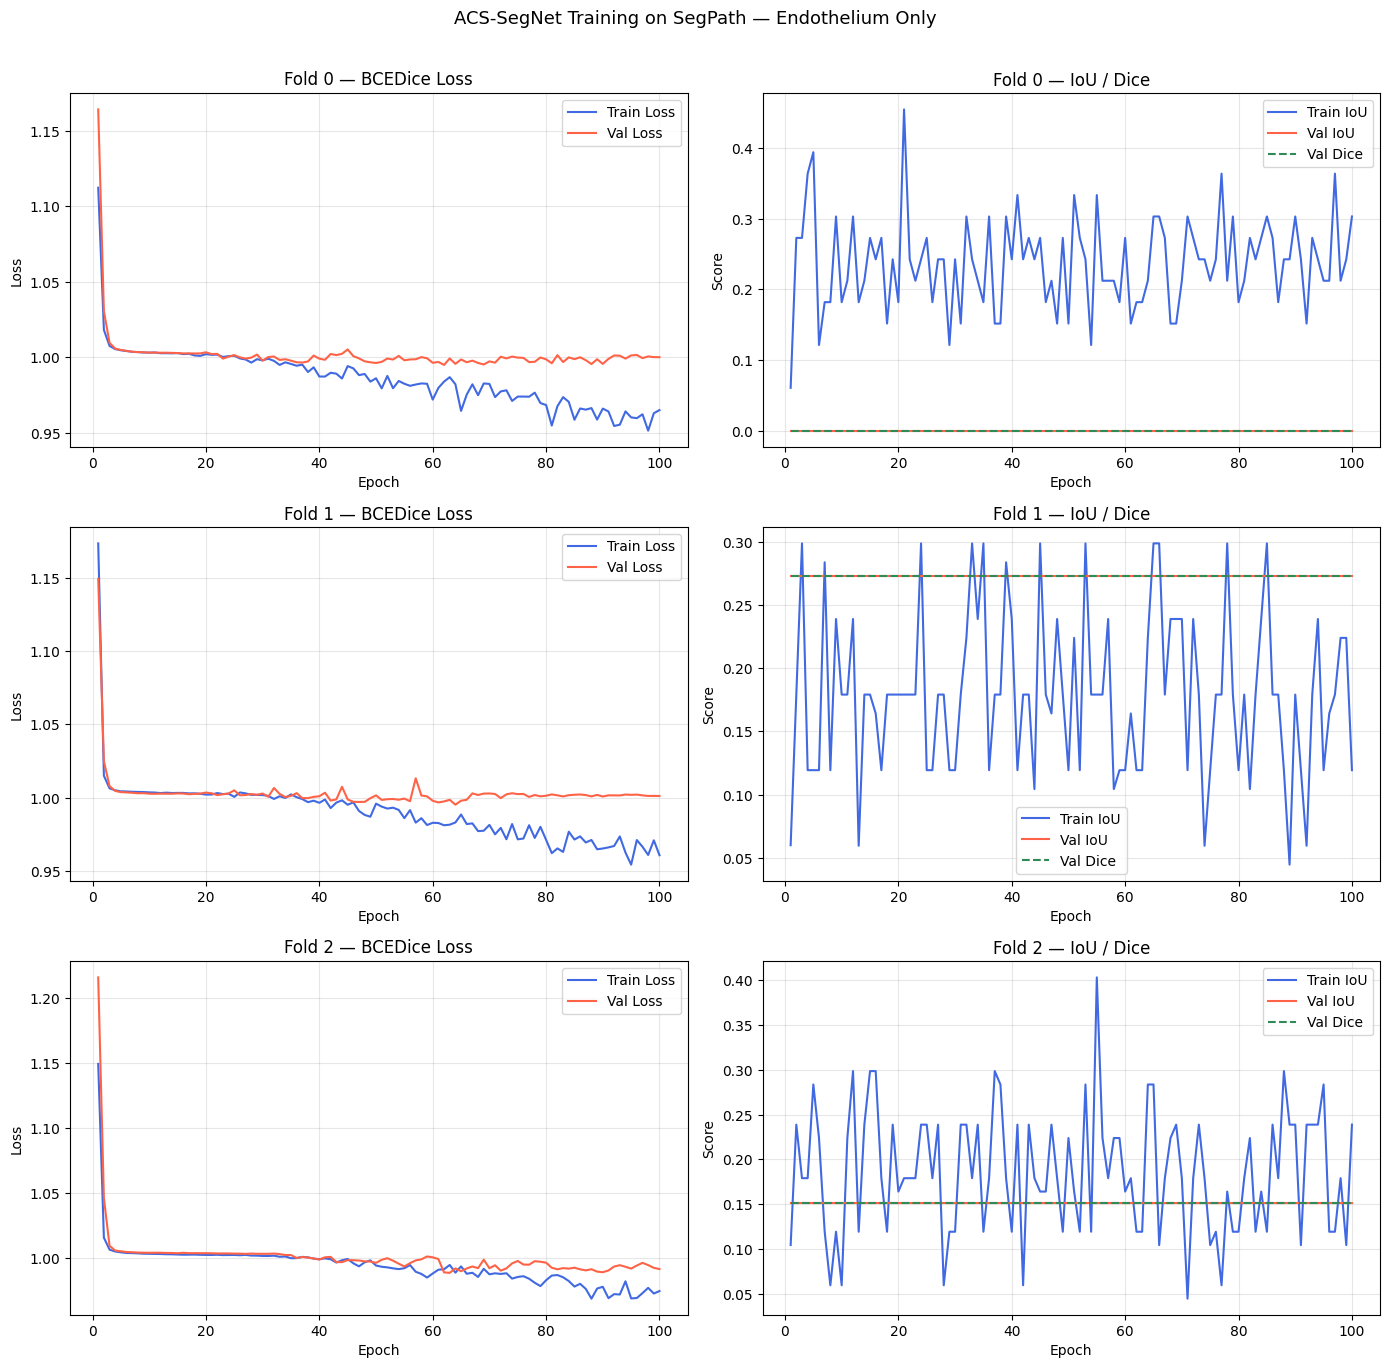

Saved → /content/drive/MyDrive/ACS_SegNet_Endothelium/training_curves.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(CFG['n_folds'], 2, figsize=(14, 4.5 * CFG['n_folds']))

for fi in range(CFG['n_folds']):
    h   = fold_histories[fi]
    eps = range(1, len(h['train_loss']) + 1)

    ax_l = axes[fi][0]
    ax_l.plot(eps, h['train_loss'], label='Train Loss', color='royalblue')
    ax_l.plot(eps, h['val_loss'],   label='Val Loss',   color='tomato')
    ax_l.set_title(f'Fold {fi} — BCEDice Loss')
    ax_l.set_xlabel('Epoch'); ax_l.set_ylabel('Loss')
    ax_l.legend(); ax_l.grid(alpha=0.3)

    ax_m = axes[fi][1]
    ax_m.plot(eps, h['train_iou'],  label='Train IoU',  color='royalblue')
    ax_m.plot(eps, h['val_iou'],    label='Val IoU',    color='tomato')
    ax_m.plot(eps, h['val_dice'],   label='Val Dice',   color='seagreen', linestyle='--')
    ax_m.set_title(f'Fold {fi} — IoU / Dice')
    ax_m.set_xlabel('Epoch'); ax_m.set_ylabel('Score')
    ax_m.legend(); ax_m.grid(alpha=0.3)

plt.suptitle('ACS-SegNet Training on SegPath — Endothelium Only',
             fontsize=13, y=1.01)
plt.tight_layout()
p = os.path.join(CFG['drive_save'], 'training_curves.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', p)

## Cell 11 — Load Best Checkpoint & Final Validation

In [14]:
# Pick the fold with the highest best_iou automatically
EVAL_FOLD = max(fold_results, key=fold_results.get)
print(f'Best fold: {EVAL_FOLD}  (val IoU = {fold_results[EVAL_FOLD]:.4f})')

ckpt = os.path.join(CFG['checkpoint_dir'], f'ACSSegNet_fold{EVAL_FOLD}_best.pth')
eval_model = build_model()
eval_model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
eval_model.eval()
print(f'Loaded: {ckpt}')

_, eval_val_loader = get_dataloaders(EVAL_FOLD)
criterion = BCEDiceLoss().to(DEVICE)
val_m = validate(eval_model, eval_val_loader, criterion)

print(f'\n── Final Validation Metrics (Fold {EVAL_FOLD}) ──────────────')
metric_names = ['iou','dice','SE','PC','F1','SP','ACC']
full_names   = ['IoU','Dice','Sensitivity','Precision','F1','Specificity','Accuracy']
for k, name in zip(metric_names, full_names):
    print(f'  {name:<15}: {val_m[k].avg:.4f}')

Best fold: 1  (val IoU = 0.2727)


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | UNEXPECTED |  | 
decode_head.batch_norm.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.num_batches_tracked    | UNEXPECTED |  | 
decode_head.batch_norm.running_mean           | UNEXPECTED |  | 
decode_head.batch_norm.weight                 | UNEXPECTED |  | 
decode_head.linear_fuse.weight                | UNEXPECTED |  | 
decode_head.classifier.bias                   | UNEXPECTED |  | 
decode_head.classifier.weight                 | UNEXPECTED |  | 
decode_head.batch_norm.running_var            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ACS-SegNet parameters: 50.4 M
Loaded: /content/checkpoints_endothelium/ACSSegNet_fold1_best.pth
  [SegPath1_train.txt]  67 samples
  [SegPath1_val.txt]  33 samples

── Final Validation Metrics (Fold 1) ──────────────
  IoU            : 0.2727
  Dice           : 0.2727
  Sensitivity    : 0.0000
  Precision      : 0.0000
  F1             : 0.0000
  Specificity    : 0.7273
  Accuracy       : 0.7269


## Cell 12 — Qualitative Results (3 samples from endothelium)

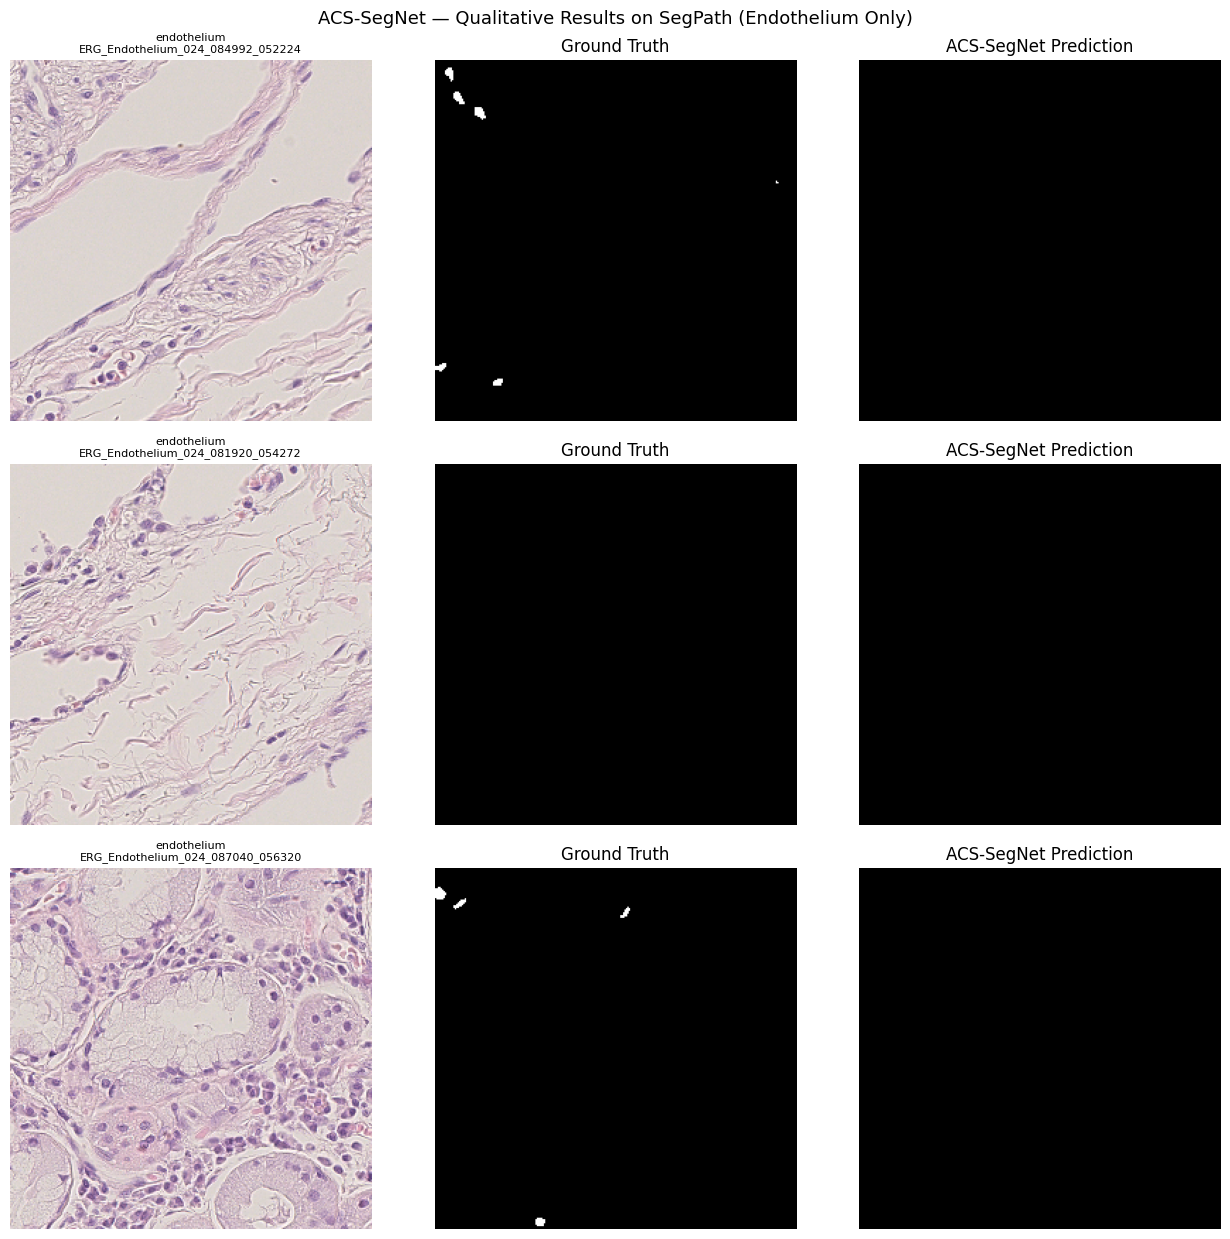

Saved → /content/drive/MyDrive/ACS_SegNet_Endothelium/qualitative_results.png


In [15]:
N_PER_CLASS = 3   # show 3 endothelium samples
cell_types  = list(CFG['cell_types'].keys())
n_rows      = len(cell_types) * N_PER_CLASS

fig, axes = plt.subplots(n_rows, 3, figsize=(13, 4.2 * n_rows))

# Collect N_PER_CLASS samples per cell type from the validation set
collected = defaultdict(list)

eval_model.eval()
with torch.no_grad():
    for batch in eval_val_loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label']
        stems  = batch['stem']
        preds  = torch.sigmoid(eval_model(imgs)).cpu()

        for b in range(imgs.size(0)):
            ct = stems[b].split('__')[0]
            if len(collected[ct]) < N_PER_CLASS:
                collected[ct].append({
                    'img' : imgs[b].cpu().numpy().transpose(1, 2, 0),
                    'mask': labels[b, 0].numpy(),
                    'pred': (preds[b, 0].numpy() > 0.5).astype('uint8'),
                    'stem': stems[b],
                })

        if all(len(v) >= N_PER_CLASS for v in collected.values()):
            break

row = 0
for ct in cell_types:
    for entry in collected.get(ct, []):
        base_id = entry['stem'].split('__')[1] if '__' in entry['stem'] else entry['stem']
        short   = base_id[:35] + '...' if len(base_id) > 35 else base_id

        axes[row][0].imshow(entry['img'])
        axes[row][0].set_title(f"{ct.replace('_',' ')}\n{short}", fontsize=8)
        axes[row][0].axis('off')

        axes[row][1].imshow(entry['mask'], cmap='gray')
        axes[row][1].set_title('Ground Truth')
        axes[row][1].axis('off')

        axes[row][2].imshow(entry['pred'], cmap='gray')
        axes[row][2].set_title('ACS-SegNet Prediction')
        axes[row][2].axis('off')

        row += 1

plt.suptitle('ACS-SegNet — Qualitative Results on SegPath (Endothelium Only)', fontsize=13)
plt.tight_layout()
p = os.path.join(CFG['drive_save'], 'qualitative_results.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', p)

## Cell 13 — Endothelium Validation Metrics Summary


── Endothelium Validation Metrics (Best Fold) ───────────────────────────
  IoU            : 0.6970  (std=0.4596, n=33)
  Dice           : 0.6970  (std=0.4596, n=33)
  Sensitivity    : 0.0000  (std=0.0000, n=33)
  Precision      : 0.0000  (std=0.0000, n=33)
  F1             : 0.0000  (std=0.0000, n=33)
  Specificity    : 0.3030  (std=0.4596, n=33)
  Accuracy       : 0.3026  (std=0.4589, n=33)


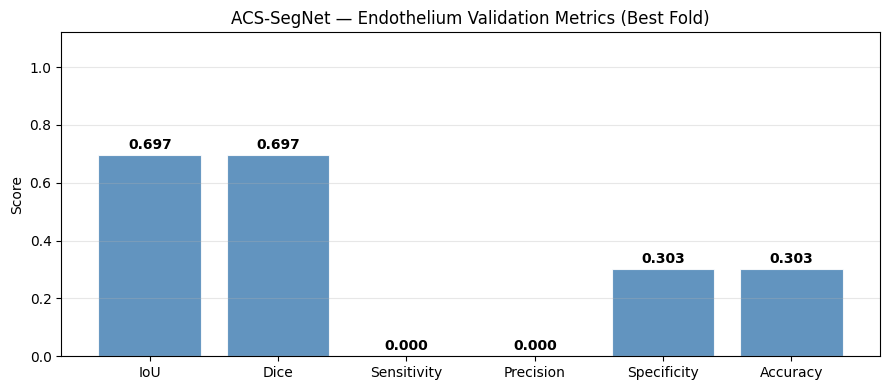

Saved → /content/drive/MyDrive/ACS_SegNet_Endothelium/endothelium_metrics.png


In [16]:
from collections import defaultdict
import numpy as np, matplotlib.pyplot as plt, os

per_class = defaultdict(lambda: defaultdict(list))

eval_model.eval()
with torch.no_grad():
    for batch in eval_val_loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        stems  = batch['stem']
        preds  = eval_model(imgs)

        for b in range(imgs.size(0)):
            ct = stems[b].split('__')[0]
            iou, dice, SE, PC, F1, SP, ACC = iou_score(preds[b:b+1], labels[b:b+1])
            for k, v in zip(['iou','dice','SE','PC','F1','SP','ACC'], [iou,dice,SE,PC,F1,SP,ACC]):
                per_class[ct][k].append(v)

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n── Endothelium Validation Metrics (Best Fold) ───────────────────────────')
ct = 'endothelium'
d  = per_class.get(ct, {})
if d:
    n = len(d['iou'])
    for metric, fullname in zip(
        ['iou','dice','SE','PC','F1','SP','ACC'],
        ['IoU','Dice','Sensitivity','Precision','F1','Specificity','Accuracy']
    ):
        print(f'  {fullname:<15}: {np.mean(d[metric]):.4f}  (std={np.std(d[metric]):.4f}, n={n})')
else:
    print('  No endothelium samples found in eval loader.')

# ── Bar chart ─────────────────────────────────────────────────────────────────
metrics_to_plot  = ['iou', 'dice', 'SE', 'PC', 'SP', 'ACC']
metric_labels    = ['IoU', 'Dice', 'Sensitivity', 'Precision', 'Specificity', 'Accuracy']

if d:
    vals = [np.mean(d[m]) for m in metrics_to_plot]
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(metric_labels, vals, color='steelblue', alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.set_title('ACS-SegNet — Endothelium Validation Metrics (Best Fold)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    p = os.path.join(CFG['drive_save'], 'endothelium_metrics.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved →', p)


## Cell 14 — Save Results JSON to Drive

In [17]:
import json, datetime

results_log = {
    'timestamp'     : datetime.datetime.now().isoformat(),
    'model'         : 'ACS-SegNet (ResNet34 + SegFormer-B2 + CBAM)',
    'dataset'       : 'SegPath (endothelium only)',
    'config'        : {k: str(v) for k, v in CFG.items()},
    'fold_best_iou' : {str(k): round(float(v), 6) for k, v in fold_results.items()},
    'mean_iou'      : round(float(np.mean(ious)), 6),
    'std_iou'       : round(float(np.std(ious)),  6),
    'per_class'     : {
        ct: {m: round(float(np.mean(vals)), 6) for m, vals in metrics.items()}
        for ct, metrics in per_class.items()
    },
}

log_path = os.path.join(CFG['drive_save'], 'results_summary.json')
with open(log_path, 'w') as f:
    json.dump(results_log, f, indent=2)

print('Results saved to:', log_path)
print()
print(json.dumps(results_log, indent=2))

Results saved to: /content/drive/MyDrive/ACS_SegNet_Endothelium/results_summary.json

{
  "timestamp": "2026-06-30T12:27:06.235017",
  "model": "ACS-SegNet (ResNet34 + SegFormer-B2 + CBAM)",
  "dataset": "SegPath (endothelium only)",
  "config": {
    "data_root": "/content/SegPath_sorted",
    "data_dir": "/content/ACS_data_endothelium",
    "cell_types": "{'endothelium': ('_HE', '_mask')}",
    "img_size": "256",
    "num_classes": "1",
    "segformer_var": "nvidia/segformer-b2-finetuned-ade-512-512",
    "resnet_enc": "resnet34",
    "decoder_ch": "(256, 128, 64, 32, 16)",
    "simple_fusion": "1",
    "epochs": "100",
    "batch_size": "4",
    "lr": "0.01",
    "momentum": "0.9",
    "weight_decay": "0.0001",
    "n_folds": "3",
    "seed": "42",
    "checkpoint_dir": "/content/checkpoints_endothelium",
    "result_dir": "/content/results_endothelium",
    "drive_save": "/content/drive/MyDrive/ACS_SegNet_Endothelium"
  },
  "fold_best_iou": {
    "0": 1e-06,
    "1": 0.272728,
   

---
## Optional — Single Endothelium Image Inference

Run inference on any new SegPath endothelium tile.  
Edit the path below and run the cell — no retraining needed.

Note: many endothelium tiles have empty ground-truth masks, so predictions may legitimately
be all-background for some samples.


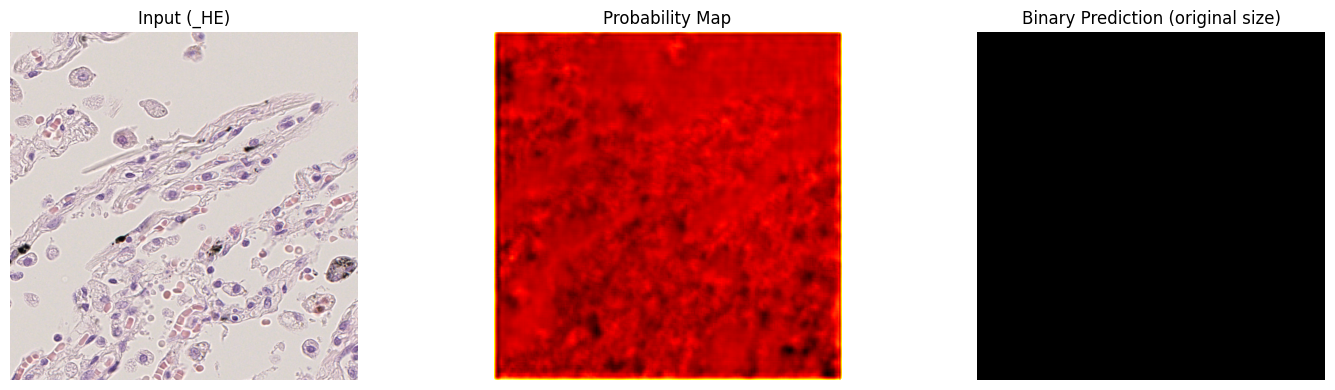

In [18]:
# ── EDIT: path to any _HE.png image ──────────────────────────────────────────
TEST_IMG = '/content/SegPath_sorted/endothelium/images/ERG_Endothelium_024_067584_052224_HE.png'
# ─────────────────────────────────────────────────────────────────────────────

from albumentations import Compose, Resize

orig = cv2.cvtColor(cv2.imread(TEST_IMG), cv2.COLOR_BGR2RGB)
H0, W0 = orig.shape[:2]

resized = Compose([Resize(CFG['img_size'], CFG['img_size'])])(image=orig)['image']
inp     = torch.tensor((resized / 255.0).transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

eval_model.eval()
with torch.no_grad():
    prob = torch.sigmoid(eval_model(inp))[0, 0].cpu().numpy()

pred_bin  = (prob > 0.5).astype('uint8') * 255
pred_full = cv2.resize(pred_bin, (W0, H0), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(orig);             axes[0].set_title('Input (_HE)');       axes[0].axis('off')
axes[1].imshow(prob, cmap='hot'); axes[1].set_title('Probability Map');   axes[1].axis('off')
axes[2].imshow(pred_full, cmap='gray'); axes[2].set_title('Binary Prediction (original size)'); axes[2].axis('off')
plt.tight_layout()
plt.show()